In [14]:
import networkx as nx
import matplotlib.pyplot as plt
from py_modules.utils import calc_ANC_score
import os
import pandas as pd
from py_modules.morPOP_utils import prep_G_for_tensor

export_path = os.path.join("Z_manuscript_vis", 'anc_example_plts')
os.makedirs(export_path, exist_ok=True)

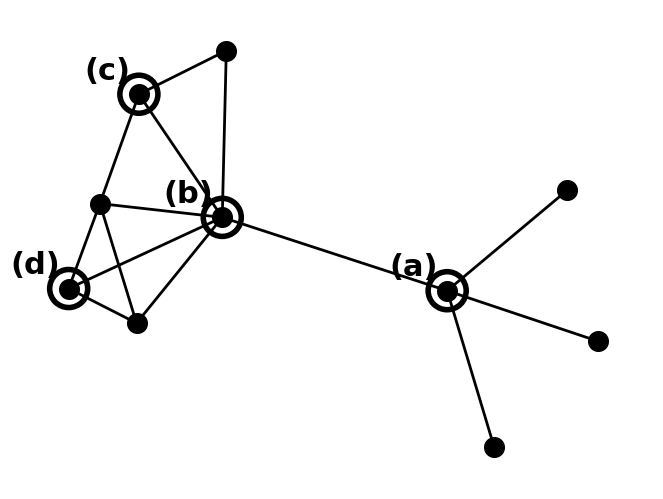

In [124]:
G = nx.Graph()

edges_to_add = [
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 5),
    (1, 6),
    (2, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (5, 6),
    (1, 7),
    (7, 8),
    (7, 9),
    (7, 10),
]


nodes_to_remove = [7, 1, 5, 3]

# add edges to the graph
for edge in edges_to_add:
    G.add_edge(*edge)

# get spring layout
pos = nx.spring_layout(G, k=0.1, iterations=100)

# draw the graph
nx.draw(G, pos, node_size=200, node_color="black", edge_color="black", width=2)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=nodes_to_remove,
    node_size=750,
    node_color="none",      # no fill
    edgecolors="black",       # outline color
    linewidths=4
)

# add (a), (b), (c), etc. to the upper-left of the nodes to be removed
for i, node in enumerate(nodes_to_remove):
    label = f"({chr(ord('a') + i)})"
    x, y = pos[node]
    # you can adjust these offsets (0.03, 0.03) to position labels precisely
    plt.text(
        x - 0.03,
        y + 0.03,
        label,
        fontsize=22,
        color="black",
        fontweight="bold",
        horizontalalignment="right",
        verticalalignment="bottom"
    )



# save the plot
plt.savefig(os.path.join(export_path, "1.pdf"))



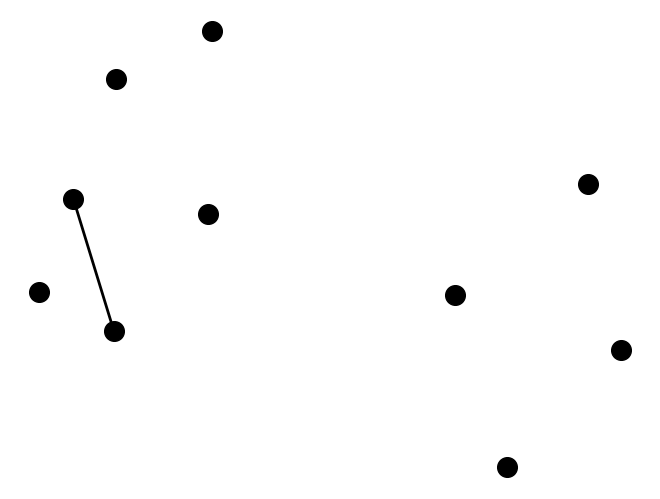

In [125]:
# remove all edges connected to the nodes to be removed
G_modified = G.copy()
for node in nodes_to_remove:
    G_modified.remove_edges_from(list(G_modified.edges(node)))

nx.draw(G_modified, pos, node_size=200, node_color="black", edge_color="black", width=2)

# save the plot
plt.savefig(os.path.join(export_path, "2.pdf"))


0.2833333333333333


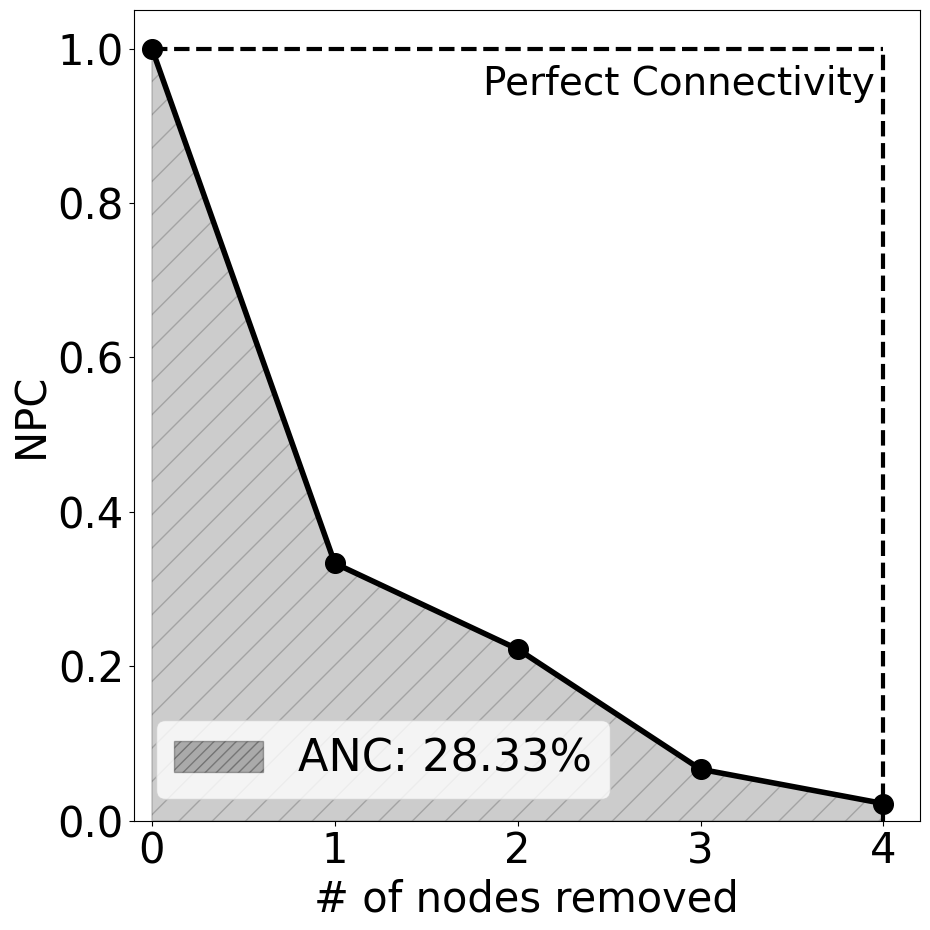

In [156]:
anc_score, scores = calc_ANC_score(G, nodes_to_remove, return_scores=True)

# make all fonts much larger
plt.rcParams.update({'font.size': 30})
print(anc_score)

plt.figure(figsize=(10, 10))

plt.ylim(0, 1.05)
plt.xlim(-0.1, len(scores)-0.8)
plt.xlabel("# of nodes removed")
plt.ylabel("NPC")
plt.xticks(range(len(scores)), range(len(scores)))
plt.plot(scores, color="black", linewidth=4)
# plt.legend(["ANC: " + str(anc_score.round(2))])
from matplotlib.patches import Patch
legend_element = Patch(facecolor='black', 
                      alpha=0.3,
                      hatch='///',
                      edgecolor='black',
                      label="ANC: " + str(round(100 * anc_score, 2)) + "%")

# Use the custom patch in the legend
plt.legend(handles=[legend_element], fontsize=32, loc='lower left')


plt.fill_between(range(len(scores)), scores, 
                 color='black', 
                 alpha=0.2,  # Controls transparency
                 hatch='/',  # Creates diagonal line pattern
                 edgecolor='black')


plt.plot([0, len(scores) - 1], [1, 1], linestyle='dashed', color='black', linewidth=3)

# Add a vertical dashed line from (len(scores),0) to (len(scores),1)
plt.plot([len(scores) - 1, len(scores) - 1], [0, 1], linestyle='dashed', color='black', linewidth=3)

# # Add text under the corner
plt.text(len(scores) - 1.05, 0.94, "Perfect Connectivity", fontsize=28, color='black', ha='right')

plt.scatter(range(len(scores)), scores, s=200, color="black", zorder=3)
plt.tight_layout()

plt.savefig(os.path.join(export_path, "3.png"))
plt.show()

# save the plot



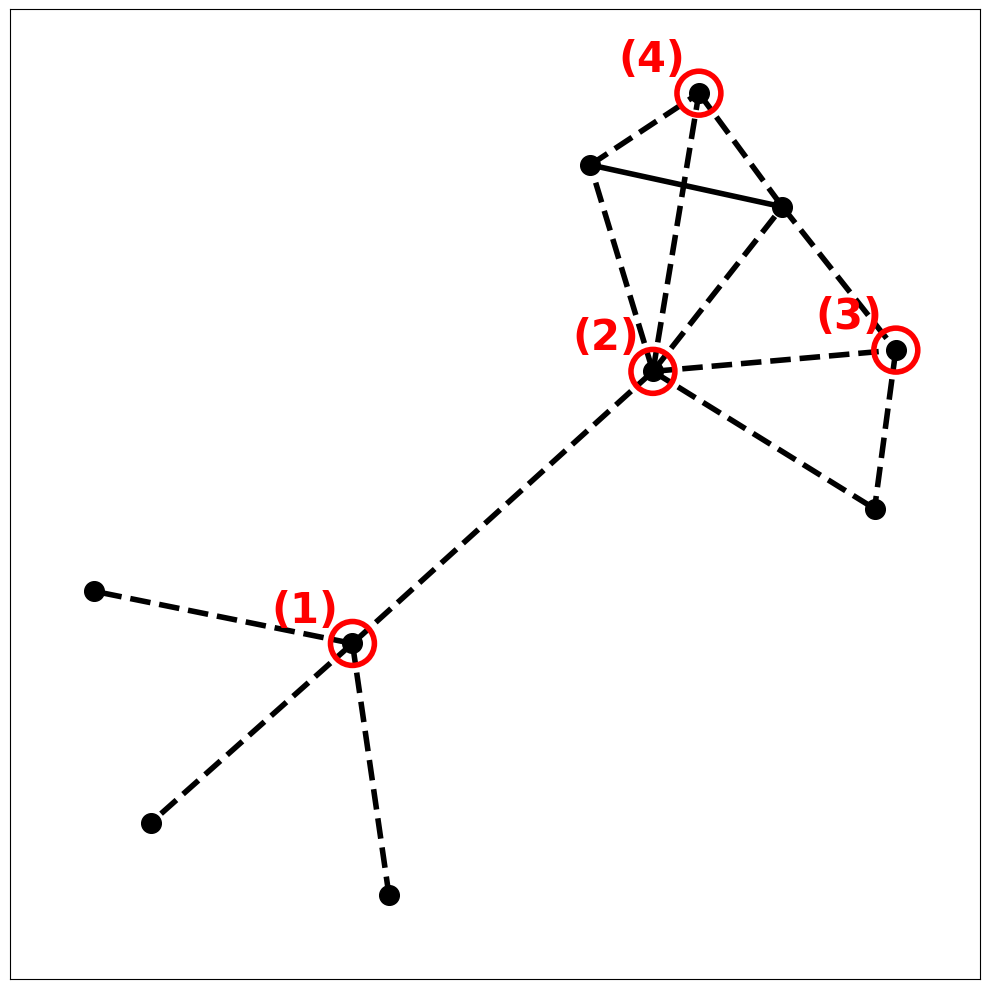

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import os

G = nx.Graph()

edges_to_add = [
    (1, 2),
    (1, 3),
    (1, 4),
    (1, 5),
    (1, 6),
    (2, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (5, 6),
    (1, 7),
    (7, 8),
    (7, 9),
    (7, 10),
]

nodes_to_remove = [7, 1, 5, 3]

# Add edges to the graph
for edge in edges_to_add:
    G.add_edge(*edge)

plt.figure(figsize=(10, 10))
# Get spring layout
pos = nx.spring_layout(G, k=0.1, iterations=100)

# Split edges into those connected to nodes_to_remove (dashed) and others (solid)
edges_to_dash = [(u, v) for u, v in G.edges() if u in nodes_to_remove or v in nodes_to_remove]
edges_normal = [(u, v) for u, v in G.edges() if u not in nodes_to_remove and v not in nodes_to_remove]

# Draw edges: normal first, then dashed
nx.draw_networkx_edges(G, pos, edgelist=edges_normal, edge_color="black", width=4)
nx.draw_networkx_edges(G, pos, edgelist=edges_to_dash, edge_color="black", width=4, style="--")

# Draw all nodes normally
nx.draw_networkx_nodes(G, pos, nodelist=G.nodes(), node_size=200, node_color="black")

# Overlay nodes_to_remove with outlined circles
nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=nodes_to_remove,
    node_size=1000,
    node_color="none",
    edgecolors="red",
    linewidths=4,
)

# Add labels (a), (b), (c), etc.
for i, node in enumerate(nodes_to_remove):
    label = f"({chr(ord('1') + i)})"
    x, y = pos[node]
    plt.text(
        x - 0.03,
        y + 0.03,
        label,
        fontsize=30,
        color="red",
        fontweight="bold",
        horizontalalignment="right",
        verticalalignment="bottom",
    )

# Save the plot
export_path = "."  # Adjust the export path as needed
plt.tight_layout()
plt.savefig(os.path.join(export_path, "1_new.pdf"))
plt.show()

## Main results tables


In [23]:
G_dict = {'G_label': [], 'num_nodes': [], 'num_edges': [], 'budget': []}
DATA_PATH = 'Data/Data_benchmark_32instance'
for file in os.listdir(DATA_PATH):
    if not file.endswith('.txt'):
        print(f"Skipping {file} because it is not a txt file")
        continue

    G_name = file.split('.')[0]
    G = prep_G_for_tensor(os.path.join(DATA_PATH, file))
    G_dict['G_label'].append(G_name)
    G_dict['num_nodes'].append(G.number_of_nodes())
    G_dict['num_edges'].append(G.number_of_edges())
    G_dict['budget'].append(int(G.number_of_nodes() * 0.1))

# for i in range(20):
#     G = prep_G_for_tensor(f'Data/PPI_networks/graph_{i}.txt')
#     G_dict['G_label'].append(f'PPI_{i}')
#     G_dict['num_nodes'].append(G.number_of_nodes())
#     G_dict['num_edges'].append(G.number_of_edges())
#     G_dict['budget'].append(int(G.number_of_nodes() * 0.1))
    
G_names_df = pd.DataFrame(G_dict)

# sort by num_nodes
G_names_df = G_names_df.sort_values(by='num_nodes')




G_names_df


,G_label,num_nodes,num_edges,budget
20,Bovine,121,190,12
23,Circuit,252,399,25
2,Treni_Roma,255,272,25
22,Ecoli,328,456,32
24,USAir97,332,2126,33
6,humanDiseasome,516,1188,51
25,socfb-Caltech36,769,16656,76
28,soc-wiki-Vote,889,2914,88
12,socfb-Reed98,962,18812,96
30,Hamilton1000,1000,1998,100


In [24]:
labels_interest = ['MTSSL_MEGA_CrossAttention_1l_freeze_BA_FINDER_noProc',
                   'ORIGINAL_BA_FINDER',
                   'CI',
                   'HDA',
                   'degree',
                   'random']

labels_interest_present = ['MUSE-CN',
                           'FINDER',
                           'CI',
                           'HDA',
                           'degree',
                           'random']


results_path = 'Evals/MUSE_CN_evals/results.csv'

results_df = pd.read_csv(results_path)

results_df = results_df[results_df['method_name'].isin(labels_interest)]

# rename method_name to labels_interest_present
results_df['method_name'] = results_df['method_name'].replace(labels_interest, labels_interest_present)

print(results_df.shape)


results_df = results_df.merge(G_names_df, on='G_label', how='left')
results_df['anc_percentage'] = 100 * results_df['ANC']




METRICS = ['anc_percentage', 'end_pairwise_connectivity']


(192, 6)


In [25]:
def create_latex_table(results_df, G_names_df, metric, labels_interest=None):
    # get the df where each row is a graph, and columns are the metric values for each method
    metric_df = results_df.pivot(index='G_label', columns='method_name', values=metric)

    # merge with G_names_df on G_label
    metric_df = metric_df.merge(G_names_df, on='G_label', how='left')
    
    # sort by num_nodes
    metric_df = metric_df.sort_values(by='num_nodes')
    
    # If specific labels are provided, filter columns
    if labels_interest is not None:
        metric_df = metric_df[['num_nodes', 'budget'] + labels_interest + ['G_label']]
    
    # Round all values to 2 decimal points
    metric_df = metric_df.round(2)
    
    # Create LaTeX table
    latex_rows = []
    
    # Header
    header = " & ".join([f"{col}" for col in labels_interest])
    latex_rows.append(f"\\begin{{tabular}}{{l{'|c' * (len(labels_interest) + 2)}}}")
    latex_rows.append(f"Graph & |V| & b & {header} \\\\")
    latex_rows.append("\\\\\\\\\\\\hline")
    
    # Rows
    for idx, row in metric_df.iterrows():
        # Format graph label
        graph_label = row['G_label'].replace('_', '\\_')
        n = row['num_nodes']
        b = row['budget']
        
        # Find minimum (best) and second-best values in the row
        sorted_vals = sorted(row[labels_interest])
        min_val = sorted_vals[0]  # Best value (bold)
        second_best_val = sorted_vals[1] if len(sorted_vals) > 1 else None  # Second-best (underlined)
        
        # Format values, making winner bold and second-best underlined
        formatted_values = []
        for val in row[labels_interest]:
            if val == min_val:
                formatted_values.append(f"\\textbf{{{val:.2f}}}")
            elif val == second_best_val:
                formatted_values.append(f"\\underline{{{val:.2f}}}")
            else:
                formatted_values.append(f"{val:.2f}")
        
        # Join values and add to rows
        values_str = " & ".join(formatted_values)
        latex_rows.append(f"\\texttt{{{graph_label}}} & {n} & {b} & {values_str} \\\\")
    
    # Close table
    latex_rows.append("\\end{tabular}")
    
    return "\n".join(latex_rows)


In [26]:
for metric in METRICS:
    print(f"Metric: {metric}")
    # get the df where each row is a graph, and columns are the metric values for each method
    # metric_df = results_df.pivot(index='G_label', columns='method_name', values=metric)

    latex_table = create_latex_table(results_df, G_names_df, metric, labels_interest_present)
    print(latex_table)


Metric: anc_percentage
\begin{tabular}{l|c|c|c|c|c|c|c|c}
Graph & |V| & b & MUSE-CN & FINDER & CI & HDA & degree & random \\
\\\\\\hline
\texttt{Bovine} & 121 & 12 & 14.32 & 11.88 & 11.81 & \textbf{11.43} & \underline{11.53} & 89.80 \\
\texttt{Circuit} & 252 & 25 & 70.84 & 72.74 & \underline{70.57} & 72.98 & \textbf{70.00} & 88.13 \\
\texttt{Treni\_Roma} & 255 & 25 & \textbf{29.57} & 33.65 & 47.92 & 39.02 & \underline{29.64} & 32.79 \\
\texttt{Ecoli} & 328 & 32 & 16.35 & 15.86 & 15.17 & \textbf{13.50} & \underline{13.56} & 87.54 \\
\texttt{USAir97} & 332 & 33 & \textbf{46.42} & 61.28 & 62.17 & \underline{60.33} & 62.33 & 90.30 \\
\texttt{humanDiseasome} & 516 & 51 & 30.36 & 25.38 & 41.64 & \textbf{22.20} & \underline{25.37} & 81.09 \\
\texttt{socfb-Caltech36} & 769 & 76 & \textbf{85.11} & 86.50 & 86.12 & \underline{86.10} & \underline{86.10} & 88.74 \\
\texttt{soc-wiki-Vote} & 889 & 88 & \underline{71.53} & \textbf{70.41} & 78.98 & 75.81 & 77.06 & 87.52 \\
\texttt{socfb-Reed98} & 962 &

## Ablations: 1. weight freezing

In [21]:
# ABLATION_Gs = ['Enron', 'facebook', 'openflights', 'USAir97', 'Hamilton5000']
# results_path = 'Evals/MEGA_integration_benchmark_4_p10/results.csv'

ABLATION_Gs = ['PPI_13']
results_path = 'Evals/MUSE_CN_PPI_ablations/results.csv'


In [24]:
labels_interest = [
                   'MTSSL_MEGA_CrossAttention_1l_freeze_BA_FINDER_noProc',
                   'MTSSL_MEGA_finetune_BA_FINDER_noProc',
                   'MTSSL_MEGA_reset_BA_FINDER_noProc'
                   ]

labels_interest_present = [
                           'Pretraining frozen',
                           'Pretraining finetuned',
                           'No pretraining'
                           ]


results_df = pd.read_csv(results_path)

results_df = results_df[results_df['method_name'].isin(labels_interest)]

# filter results_df for Gs in ABLATION_Gs
results_df = results_df[results_df['G_label'].isin(ABLATION_Gs)]

# rename method_name to labels_interest_present
results_df['method_name'] = results_df['method_name'].replace(labels_interest, labels_interest_present)

print(results_df.shape)

print(results_df.shape[0] // len(labels_interest) == 28)

results_df = results_df.merge(G_names_df, on='G_label', how='left')
results_df['anc_percentage'] = 100 * results_df['ANC']




METRICS = ['anc_percentage', 'end_pairwise_connectivity']


(3, 6)
False


In [25]:
for metric in METRICS:
    print(f"Metric: {metric}")
    # get the df where each row is a graph, and columns are the metric values for each method
    # metric_df = results_df.pivot(index='G_label', columns='method_name', values=metric)

    latex_table = create_latex_table(results_df, G_names_df, metric, labels_interest_present)
    print(latex_table)

Metric: anc_percentage
\begin{tabular}{l|c|c|c|c|c}
Graph & |V| & b & Pretraining frozen & Pretraining finetuned & No pretraining \\
\hline
\texttt{PPI\_13} & 3480 & 348 & \textbf{83.17} & 85.34 & \underline{84.83} \\
\end{tabular}
Metric: end_pairwise_connectivity
\begin{tabular}{l|c|c|c|c|c}
Graph & |V| & b & Pretraining frozen & Pretraining finetuned & No pretraining \\
\hline
\texttt{PPI\_13} & 3480 & 348 & \textbf{0.70} & \underline{0.72} & 0.73 \\
\end{tabular}


# Ablations: 2. CrossAttention num layers

In [26]:
labels_interest = [
                    'MTSSL_MEGA_freeze_BA_FINDER_noProc',
                   'MTSSL_MEGA_CrossAttention_1l_freeze_BA_FINDER_noProc',
                   'MTSSL_MEGA_CrossAttention_2l_freeze_BA_FINDER_noProc',
                   'MTSSL_MEGA_CrossAttention_4l_freeze_BA_FINDER_noProc',
                   ]

labels_interest_present = [
    'MLP ',
    '1-l CA',
    '2-l CA',
    '4-l CA'
                           ]


results_df = pd.read_csv(results_path)

results_df = results_df[results_df['method_name'].isin(labels_interest)]

# filter results_df for Gs in ABLATION_Gs
results_df = results_df[results_df['G_label'].isin(ABLATION_Gs)]

# rename method_name to labels_interest_present
results_df['method_name'] = results_df['method_name'].replace(labels_interest, labels_interest_present)


print(results_df.shape)

print(results_df.shape[0] // len(labels_interest) == 28)

results_df = results_df.merge(G_names_df, on='G_label', how='left')
results_df['anc_percentage'] = 100 * results_df['ANC']




METRICS = ['anc_percentage', 'end_pairwise_connectivity']


(4, 6)
False


In [27]:
for metric in METRICS:
    print(f"Metric: {metric}")
    # get the df where each row is a graph, and columns are the metric values for each method
    # metric_df = results_df.pivot(index='G_label', columns='method_name', values=metric)

    latex_table = create_latex_table(results_df, G_names_df, metric, labels_interest_present)
    print(latex_table)

Metric: anc_percentage
\begin{tabular}{l|c|c|c|c|c|c}
Graph & |V| & b & MLP  & 1-l CA & 2-l CA & 4-l CA \\
\hline
\texttt{PPI\_13} & 3480 & 348 & \underline{84.59} & \textbf{83.17} & 84.75 & 84.87 \\
\end{tabular}
Metric: end_pairwise_connectivity
\begin{tabular}{l|c|c|c|c|c|c}
Graph & |V| & b & MLP  & 1-l CA & 2-l CA & 4-l CA \\
\hline
\texttt{PPI\_13} & 3480 & 348 & \underline{0.73} & \textbf{0.70} & \underline{0.73} & \underline{0.73} \\
\end{tabular}


# Benchmark tables

In [11]:
import pandas as pd
import re

# LaTeX table string
latex_table = r"""
    \begin{tabular}{l|c|c|c|c|c|c|c|c}
        Graph & |V| & b & MUSE-CN & FINDER & CI & HDA & degree & random \\
        \hline
        \texttt{Bovine} & 121 & 12 & 14.32 & 11.88 & 11.81 & \textbf{11.43} & \underline{11.53} & 89.80 \\
        \texttt{Circuit} & 252 & 25 & 70.84 & 72.74 & \underline{70.57} & 72.98 & \textbf{70.00} & 88.13 \\
        \texttt{Treni\_Roma} & 255 & 25 & \textbf{29.57} & 33.65 & 47.92 & 39.02 & \underline{29.64} & 32.79 \\
        \texttt{Ecoli} & 328 & 32 & 16.35 & 15.86 & 15.17 & \textbf{13.50} & \underline{13.56} & 87.54 \\
        \texttt{USAir97} & 332 & 33 & \textbf{46.42} & 61.28 & 62.17 & \underline{60.33} & 62.33 & 90.30 \\
        \texttt{humanDiseasome} & 516 & 51 & 30.36 & 25.38 & 41.64 & \textbf{22.20} & \underline{25.37} & 81.09 \\
        \texttt{socfb-Caltech36} & 769 & 76 & \textbf{85.11} & 86.50 & 86.12 & \underline{86.10} & \underline{86.10} & 88.74 \\
        \texttt{soc-wiki-Vote} & 889 & 88 & \underline{71.53} & \textbf{70.41} & 78.98 & 75.81 & 77.06 & 87.52 \\
        \texttt{socfb-Reed98} & 962 & 96 & \textbf{89.06} & 89.34 & 89.25 & \underline{89.23} & 89.25 & 89.69 \\
        \texttt{Hamilton1000} & 1000 & 100 & \textbf{84.91} & \underline{88.79} & 90.16 & 90.11 & 90.18 & 90.33 \\
        \texttt{email-univ} & 1133 & 113 & \textbf{79.53} & \underline{82.13} & 85.35 & 84.39 & 84.67 & 89.40 \\
        \texttt{EU\_flights} & 1191 & 119 & \textbf{77.13} & 87.63 & 86.87 & \underline{85.22} & 86.85 & 89.50 \\
        \texttt{socfb-Haverford76} & 1446 & 144 & \textbf{90.11} & 90.15 & 90.16 & \underline{90.14} & 90.16 & 90.34 \\
        \texttt{openflights} & 1491 & 149 & \textbf{40.08} & 58.21 & 53.72 & \underline{50.10} & 53.75 & 88.22 \\
        \texttt{OClinks} & 1899 & 189 & \textbf{60.85} & 64.74 & 65.29 & \underline{63.86} & 64.66 & 88.15 \\
        \texttt{yeast1} & 1966 & 196 & 20.37 & \underline{16.77} & 23.23 & \textbf{16.30} & 16.82 & 59.03 \\
        \texttt{Hamilton2000} & 2000 & 200 & \textbf{84.57} & \underline{89.03} & 90.32 & 90.15 & 90.25 & 90.33 \\
        \texttt{socfb-Bowdoin47} & 2252 & 225 & \textbf{89.45} & 89.84 & 89.86 & \underline{89.80} & 89.84 & 89.93 \\
        \texttt{Hamilton3000e} & 3000 & 300 & \textbf{84.65} & \underline{88.49} & 90.28 & 90.28 & 90.28 & 90.32 \\
        \texttt{Hamilton3000d} & 3000 & 300 & \textbf{84.61} & \underline{88.56} & 90.15 & 90.15 & 90.10 & 90.29 \\
        \texttt{Hamilton3000c} & 3000 & 300 & \textbf{84.93} & \underline{88.98} & 90.28 & 90.17 & 90.20 & 90.28 \\
        \texttt{Hamilton3000b} & 3000 & 300 & \textbf{84.77} & \underline{88.15} & 90.23 & 90.26 & 90.23 & 90.32 \\
        \texttt{Hamilton3000a} & 3000 & 300 & \textbf{84.67} & \underline{88.42} & 90.28 & 90.27 & 90.31 & 90.30 \\
        \texttt{PPI\_1} & 3021 & 302 & \textbf{84.27} & 86.51 & 86.42 & \underline{85.86} & 86.35 & 89.89 \\
        \texttt{PPI\_2} & 3163 & 316 & \textbf{84.53} & 86.84 & 86.67 & \underline{86.15} & 86.64 & 89.98 \\
        \texttt{PPI\_3} & 3312 & 331 & \textbf{85.36} & 87.56 & 87.40 & \underline{86.73} & 87.35 & 89.96 \\
        \texttt{PPI\_4} & 3480 & 348 & \textbf{83.17} & 86.14 & 86.02 & \underline{85.18} & 85.91 & 90.08 \\
        \texttt{Hamilton4000} & 4000 & 400 & \textbf{84.97} & \underline{88.60} & 90.27 & 90.16 & 90.19 & 90.33 \\
        \texttt{facebook} & 4039 & 403 & \textbf{65.12} & 86.23 & \underline{75.30} & 84.58 & 86.51 & 90.21 \\
        \texttt{powergrid} & 4941 & 494 & 39.38 & 41.83 & 43.87 & \textbf{36.22} & \underline{39.35} & 83.33 \\
        \texttt{Hamilton5000} & 5000 & 500 & \textbf{84.80} & \underline{88.48} & 90.29 & 90.21 & 90.27 & 90.32 \\
        \texttt{Enron} & 33696 & 3369 & \textbf{19.74} & 25.43 & 26.23 & \underline{20.57} & 22.84 & 86.73 \\
        \end{tabular}

"""

# Remove LaTeX formatting and extract rows
cleaned_rows = []
for line in latex_table.split("\\\\"):
    line = re.sub(r"\\texttt{(.*?)}", r"\1", line)  # Remove \texttt{}
    line = re.sub(r"\\textbf{(.*?)}", r"\1", line)  # Remove \textbf{}
    line = re.sub(r"\\underline{(.*?)}", r"\1", line)  # Remove \underline{}
    line = re.sub(r"\\hline", "", line)  # Remove \hline
    line = line.strip()
    if line:
        cleaned_rows.append(line.split("&"))

# Convert to DataFrame
df = pd.DataFrame(cleaned_rows[1:], columns=[col.strip() for col in cleaned_rows[0]])

# Display the DataFrame
# import ace_tools as tools
# tools.display_dataframe_to_user(name="LaTeX Table DataFrame", dataframe=df)

# drop last row
df = df.iloc[:-1]


In [13]:
df['MUSE-CN'] = df['MUSE-CN'].astype(float)
df['FINDER'] = df['FINDER'].astype(float)

df['improvement'] = 100 * (df['MUSE-CN'] - df['FINDER']) / df['FINDER']


mean_improvement = df['improvement'].mean()

print(mean_improvement)

-4.073915135946397
